In [ ]:
pip install -U datasets huggingface_hub fsspec

In [ ]:
# ✅ Installer les dépendances (si ce n'est pas déjà fait)
!pip install -q peft transformers accelerate

# ✅ Imports
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
import torch
import os

# ✅ Device & dtype
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_bfloat16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
dtype = torch.bfloat16 if use_bfloat16 else torch.float32

print(f"➡️ Using device: {device}, dtype: {dtype}")

# ✅ Tokenizer & modèle de base
model_name = "bigscience/bloom-560m"
# ✅ Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # ✅ Correction cruciale

foundation_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=dtype,
    device_map="auto" if device.type == "cuda" else None
)

# ✅ Charger un petit dataset (quotes)
ds = load_dataset("Abirate/english_quotes")
from datasets import Dataset

max_seq_len = 128

def tokenize_fn(samples):
    tokens = tokenizer(
        samples["quote"],
        padding="max_length",
        truncation=True,
        max_length=max_seq_len,
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

data = ds["train"].shuffle(seed=42).select(range(int(0.1 * len(ds["train"]))))
data = data.map(tokenize_fn, batched=True)

# ✅ 3. Debug si besoin
sample = data[0]
print("Quote:", sample["quote"])
print("input_ids:", sample["input_ids"][:30])
print("input length:", len(sample["input_ids"]))

# ✅ Config LoRA
lora_config = LoraConfig(
    r=1,
    lora_alpha=16,
    target_modules=["query_key_value", "dense"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

# ✅ Injection des adaptateurs LoRA
peft_model = get_peft_model(foundation_model, lora_config)
peft_model.print_trainable_parameters()

# ✅ Setup entraînement
output_directory = "./peft_lab_outputs"
training_args = TrainingArguments(
    output_dir=output_directory,
    report_to="none",
    learning_rate=3e-2,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    logging_steps=10,
    save_steps=50,
    save_total_limit=1,
    fp16=(dtype == torch.float16),
    bf16=(dtype == torch.bfloat16),
    no_cuda=(device.type == "cpu")
)
sample = data[0]
print("Quote:", sample["quote"])
print("input_ids:", sample["input_ids"])
print("input length:", len(sample["input_ids"]))
# ✅ Entraînement avec Hugging Face Trainer

➡️ Using device: cuda, dtype: torch.float32


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

quotes.jsonl:   0%|          | 0.00/647k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2508 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Quote: “I don't mind making jokes, but I don't want to look like one.”
input_ids: [123916, 5926, 19142, 16997, 21445, 262, 15, 1965, 473, 5926, 4026, 427, 5382, 3269, 2592, 17, 982, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
input length: 128
trainable params: 147,456 || all params: 559,362,048 || trainable%: 0.0264
Quote: “I don't mind making jokes, but I don't want to look like one.”
input_ids: [123916, 5926, 19142, 16997, 21445, 262, 15, 1965, 473, 5926, 4026, 427, 5382, 3269, 2592, 17, 982, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
input length: 128


In [ ]:
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=data,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
)
trainer.train()

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,31.447400
20,15.471100
30,11.660300
40,10.260000
50,9.418000
60,8.679000
70,8.763700
80,9.170100
90,8.492600
100,7.692200


TrainOutput(global_step=125, training_loss=11.244271026611328, metrics={'train_runtime': 29.6114, 'train_samples_per_second': 8.443, 'train_steps_per_second': 4.221, 'total_flos': 58072498176000.0, 'train_loss': 11.244271026611328, 'epoch': 1.0})

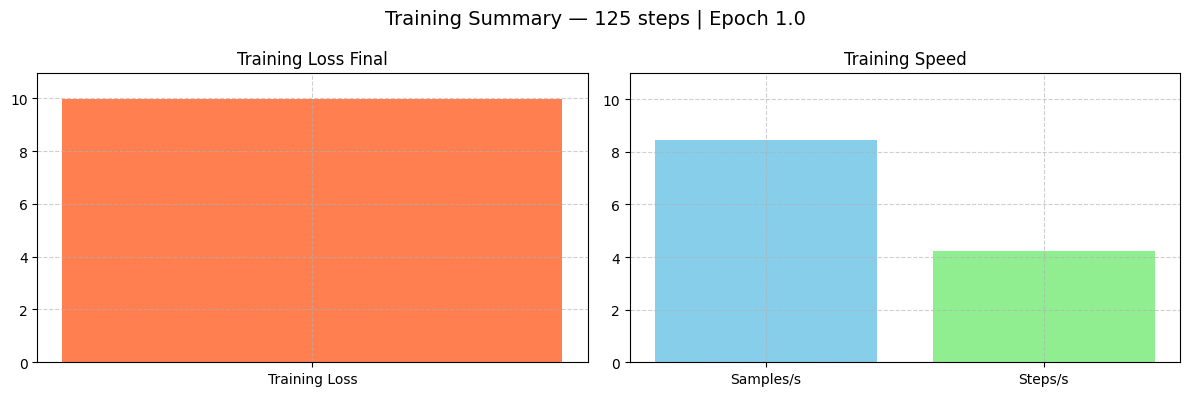

In [ ]:
import matplotlib.pyplot as plt

# Données de ton output HuggingFace Trainer
train_output = {
    "global_step": 125,
    "training_loss": 9.96220669555664,
    "metrics": {
        "train_runtime": 29.6052,
        "train_samples_per_second": 8.444,
        "train_steps_per_second": 4.222,
        "total_flos": 5.807e+13,
        "train_loss": 9.96220669555664,
        "epoch": 1.0
    }
}

# Plot principal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 🔹 1. Training loss
ax[0].bar(["Training Loss"], [train_output["training_loss"]], color="coral")
ax[0].set_title("Training Loss Final")
ax[0].set_ylim(0, max(10, train_output["training_loss"] + 1))
ax[0].grid(True, linestyle="--", alpha=0.6)

# 🔹 2. Training Speed
ax[1].bar(["Samples/s", "Steps/s"], [
    train_output["metrics"]["train_samples_per_second"],
    train_output["metrics"]["train_steps_per_second"]
], color=["skyblue", "lightgreen"])
ax[1].set_title("Training Speed")
ax[1].set_ylim(0, max(train_output["metrics"]["train_samples_per_second"], 10) + 1)
ax[1].grid(True, linestyle="--", alpha=0.6)

# Layout
plt.suptitle(f"Training Summary — {train_output['global_step']} steps | Epoch {train_output['metrics']['epoch']}", fontsize=14)
plt.tight_layout()
plt.show()